In [1]:
%pip install pandas matplotlib seaborn scikit-learn torch transformers ipywidgets


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...



Columns:
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Data types:
Unnamed: 0            int64
count                 int64
hate_speech           int64
offensive_language    int64
neither               int64
class                 int64
tweet                   str
dtype: object

Missing values:


,missing_count
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0



Duplicate rows: 0

Numeric summary:


...

,count,unique,top,freq
tweet,24783,24783,!!! RT @mayasolovely: As a woman you shouldn't...,1



Created cleaned text column: tweet_clean


,tweet,tweet_clean
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldn t complain about cle...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats cold tyga dwn bad for cuffin dat h...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she start...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true or...


,count,percentage
class,,
0,1430,5.77
1,19190,77.43
2,4163,16.80


/var/folders/2v/bn5_gh1x1b14mb5bsw0zj3fh0000gn/T/ipykernel_81631/47506999.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")


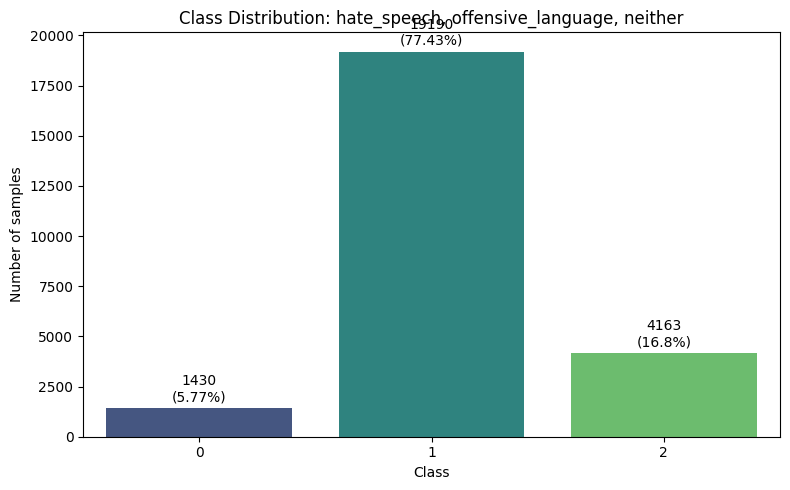


Class hate_speech - 5 examples


,class,tweet,tweet_clean
0,0,@AustinG1135 I do not like talking to you fagg...,i do not like talking to you faggot and i did ...
1,0,RT @mitchmancuso: @BrantPrintup:What straight ...,rt what straight guys take a picture of themse...
2,0,"@clinchmtn316 @sixonesixband AMERICA today, th...",america today the rule of thumb is when in dou...
3,0,"@STACCS_WNT_FOLD you tell me, coon.",you tell me coon
4,0,RT @FAAMMoverALL: This nigguh Chris Paul,rt this nigguh chris paul



Class offensive_language - 5 examples


,class,tweet,tweet_clean
0,1,Why is it everytime I go to cracker barrel the...,why is it everytime i go to cracker barrel the...
1,1,"Run that nigga, you don't want that nigga, but...",run that nigga you don t want that nigga but i...
2,1,I need a girl from Jamaica I can't fuck with t...,i need a girl from jamaica i can t fuck with t...
3,1,RT @ShadowBeatz_Inc: I know you have me blocke...,rt i know you have me blocked but next week bitch
4,1,Put ya hands up if you a Grade A bitch,put ya hands up if you a grade a bitch



Class neither - 5 examples


,class,tweet,tweet_clean
0,2,RT @chicagotribune: Chicago will not refund $7...,rt chicago will not refund million made from r...
1,2,"Sometimes, even I gotta tell these hoes to gro...",sometimes even i gotta tell these hoes to grow...
2,2,&#8216;Chillin&#8217; With My Homie Or What&#8...,chillin with my homie or what s left of him br...
3,2,.@CoryBooker is running around town delivering...,is running around town delivering food to peop...
4,2,RT @McNarstle: ...and rounding out our CNN Ebo...,rt and rounding out our cnn ebola panel tonigh...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/labeled_data.csv")

# Basic overview
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumeric summary:")
display(df.describe().T)

print("\nCategorical summary:")
display(df.describe(include=["object", "category"]).T if len(df.select_dtypes(include=["object", "category"]).columns) else pd.DataFrame({"info": ["No categorical columns"]}))

# Clean text column: URLs, @mentions, hashtags, special characters
text_col = "tweet" if "tweet" in df.columns else df.select_dtypes(include=["object", "category"]).columns[0]

df[f"{text_col}_clean"] = (
    df[text_col]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"http\S+|www\.\S+", "", regex=True)   # remove URLs
    .str.replace(r"@\w+", "", regex=True)               # remove @mentions
    .str.replace(r"#(\w+)", r"\1", regex=True)          # keep hashtag word, remove #
    .str.replace(r"[^a-z\s]", " ", regex=True)          # remove special characters/numbers
    .str.replace(r"\s+", " ", regex=True)               # normalize spaces
    .str.strip()
)

print(f"\nCreated cleaned text column: {text_col}_clean")
display(df[[text_col, f"{text_col}_clean"]].head())

class_names = ["hate_speech", "offensive_language", "neither"]
target_col = "class"

# Visualize class imbalance
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

display(
    pd.DataFrame({
        "count": class_counts,
        "percentage": class_pct
    })
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")

plt.title(f"Class Distribution: {', '.join(class_names)}")
plt.xlabel("Class")
plt.ylabel("Number of samples")

for i, cls in enumerate(class_counts.index):
    count = class_counts.loc[cls]
    pct = class_pct.loc[cls]
    ax.text(i, count + max(class_counts) * 0.01, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


sample_cols = [target_col, text_col]
clean_col = f"{text_col}_clean"
if clean_col in df.columns:
    sample_cols.append(clean_col)

for cls_value in sorted(df[target_col].dropna().unique()):
    print(f"\nClass {class_names[cls_value]} - 5 examples")
    display(
        df.loc[df[target_col] == cls_value, sample_cols]
          .sample(n=min(5, (df[target_col] == cls_value).sum()), random_state=42)
          .reset_index(drop=True)
    )

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Keep required columns
df = df[["tweet_clean", "class"]].dropna()
X = df["tweet_clean"].astype(str)
y = df["class"].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline models with TF-IDF
models = {
    "SVM": LinearSVC(),
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=None),
    "RandomForest": RandomForestClassifier(n_estimators=100, n_jobs=None)
}

baseline_predictions = {}
baseline_results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )),
        ("clf", clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    baseline_predictions[name] = {y_test.name: y_test, "y_pred": y_pred}

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted")
    })

    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


=== SVM ===
Accuracy: 0.8989
Macro F1: 0.7088
                    precision    recall  f1-score   support

       hate_speech     0.5255    0.2517    0.3404       286
offensive_language     0.9204    0.9609    0.9402      3838
           neither     0.8561    0.8355    0.8457       833

          accuracy                         0.8989      4957
         macro avg     0.7673    0.6827    0.7088      4957
      weighted avg     0.8868    0.8989    0.8897      4957


=== LogisticRegression ===
Accuracy: 0.8987
Macro F1: 0.6715
                    precision    recall  f1-score   support

       hate_speech     0.6721    0.1434    0.2363       286
offensive_language     0.9077    0.9742    0.9398      3838
           neither     0.8687    0.8103    0.8385       833

          accuracy                         0.8987      4957
         macro avg     0.8162    0.6426    0.6715      4957
      weighted avg     0.8876    0.8987    0.8822      4957


=== RandomForest ===
Accuracy: 0.9050
Macro 

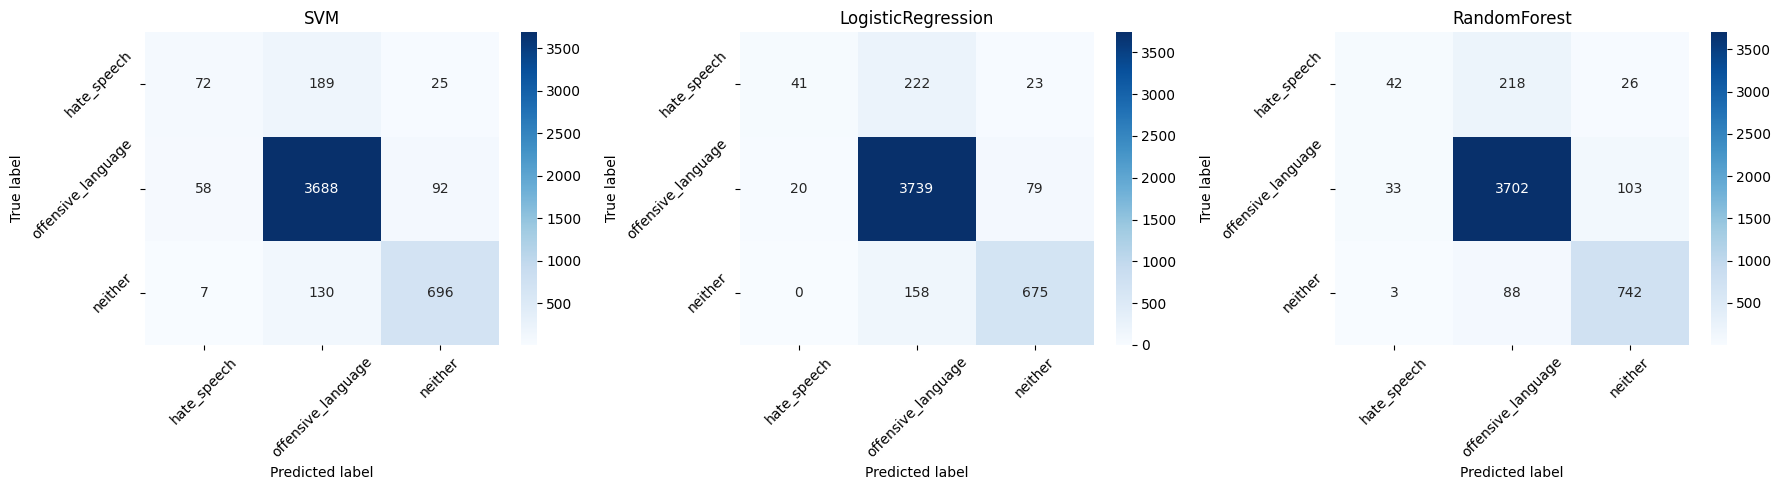


Baseline Model Comparison:


,Model,Accuracy,Macro F1,Weighted F1
0,SVM,0.898931,0.708776,0.889726
1,RandomForest,0.904983,0.681776,0.890305
2,LogisticRegression,0.898729,0.671541,0.882191


In [4]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, results) in zip(axes, baseline_predictions.items()):
    cm = confusion_matrix(results[y_test.name], results["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_yticklabels(class_names, rotation=45)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


comparison_df = pd.DataFrame(baseline_results).sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

print("\nBaseline Model Comparison:")
display(comparison_df)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Config
model_name = "distilbert-base-uncased"
num_labels = len(class_names)
max_length = 128
batch_size = 16
epochs = 2
lr = 2e-5

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist() if hasattr(texts, "tolist") else list(texts)
        self.labels = labels.tolist() if hasattr(labels, "tolist") else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = TweetDataset(X_train, y_train, tokenizer, max_length=max_length)
val_ds = TweetDataset(X_test, y_test, tokenizer, max_length=max_length)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

train_losses, val_losses, val_accuracies, val_macro_f1s = [], [], [], []

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        out = model(**batch)
        loss = out.loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            labels = batch["labels"].to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            out = model(**batch)
            val_loss += out.loss.item()

            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    val_macro_f1 = f1_score(all_labels, all_preds, average="macro")
    
    val_accuracies.append(val_acc)
    val_macro_f1s.append(val_macro_f1)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )

Using device: mps


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


No per-epoch loss history found (train_losses/val_losses). Plotting latest values only.


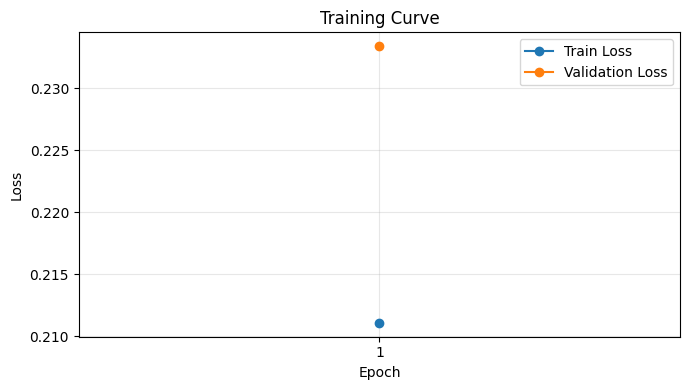

In [ ]:

epoch_axis = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epoch_axis, train_losses, marker="o", label="Train Loss")
plt.plot(epoch_axis, val_losses, marker="o", label="Validation Loss")
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epoch_axis))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epoch_axis, val_accuracies, marker="o", label="Validation Accuracy")
plt.plot(epoch_axis, val_macro_f1s, marker="o", label="Validation Macro F1")
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.xticks(list(epoch_axis))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()